<a href="https://colab.research.google.com/github/sscoconut64/Joey_DTSC3020_Fall2025/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import mlxtend
import networkx as nx
import warnings

warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

df = pd.read_csv('/content/bread_basket.csv')

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [17]:
# write your answer here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   time             20507 non-null  object
 4   period_day       20507 non-null  object
 5   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(5)
memory usage: 961.4+ KB


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [18]:
# write your answer here
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

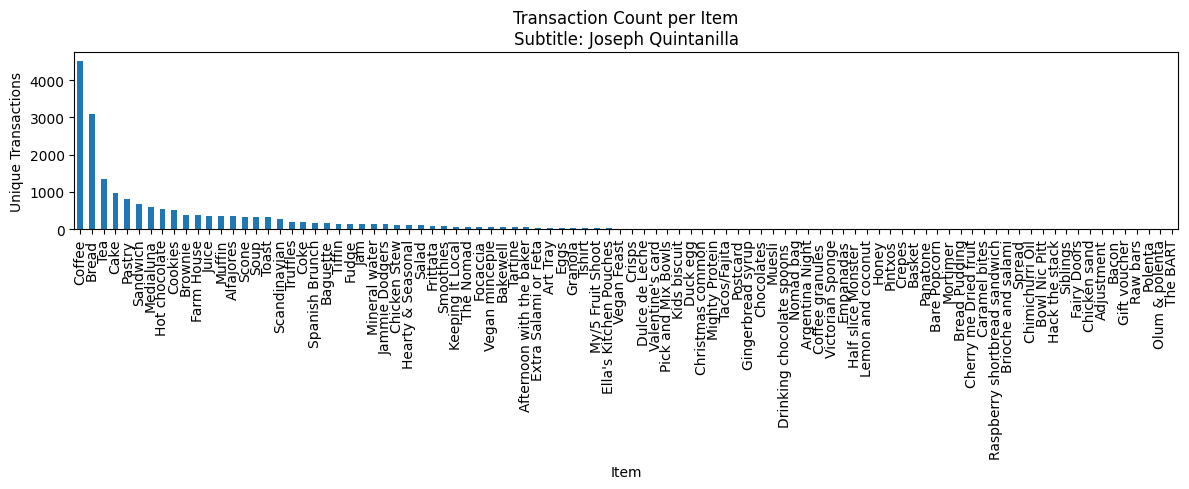

In [19]:
# write your answer  here
subtitle = "Joseph Quintanilla"
item_counts = df.groupby('item')['transaction'].nunique().sort_values(ascending=False)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [20]:
# write your answer here
print(item_counts[['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']])

item
Coffee          4528
Tea             1350
Alfajores        344
Juice            365
Chicken Stew     123
Name: transaction, dtype: int64


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [21]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth

basket = df.groupby(['transaction', 'item'])['item'].count().unstack().reset_index().fillna(0).set_index('transaction')

def encode_units(x):
    if x <= 0:
        return False
    if x >= 1:
        return True

df_transactions = basket.map(encode_units)

freq_fp = fpgrowth(df_transactions, min_support=0.02, use_colnames=True)
freq_fp

,support,itemsets
0,0.327205,(Bread)
1,0.029054,(Scandinavian)
2,0.058320,(Hot chocolate)
3,0.054411,(Cookies)
4,0.038457,(Muffin)
5,0.478394,(Coffee)
6,0.086107,(Pastry)
7,0.061807,(Medialuna)
8,0.142631,(Tea)
9,0.039197,(Farm House)


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [22]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(freq_fp, metric='confidence', min_threshold=0.1)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False)

,antecedents,consequents,support,confidence,lift
13,(Tea),(Cake),0.023772,0.166667,1.604781
14,(Cake),(Tea),0.023772,0.228891,1.604781
17,(Toast),(Coffee),0.023666,0.704403,1.472431
6,(Medialuna),(Coffee),0.035182,0.569231,1.189878
4,(Pastry),(Coffee),0.047544,0.552147,1.154168
10,(Juice),(Coffee),0.020602,0.534247,1.116750
16,(Sandwich),(Coffee),0.038246,0.532353,1.112792
12,(Cake),(Coffee),0.054728,0.526958,1.101515
11,(Coffee),(Cake),0.054728,0.114399,1.101515
3,(Cookies),(Coffee),0.028209,0.518447,1.083723


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

In [23]:
num_total_transactions = df_transactions.shape[0]

support_coffee_cake_bread = df_transactions[
    (df_transactions['Coffee'] == True) &
    (df_transactions['Cake'] == True) &
    (df_transactions['Bread'] == True)
].shape[0] / num_total_transactions

support_coffee_cake = freq_fp[freq_fp['itemsets'] == frozenset({'Coffee', 'Cake'})]['support'].iloc[0]

support_bread = freq_fp[freq_fp['itemsets'] == frozenset({'Bread'})]['support'].iloc[0]

confidence_coffee_cake_to_bread = support_coffee_cake_bread / support_coffee_cake

lift_coffee_cake_to_bread = confidence_coffee_cake_to_bread / support_bread

print(f"Support for {{Coffee, Cake, Bread}}: {support_coffee_cake_bread:.4f}")
print(f"Support for {{Coffee, Cake}}: {support_coffee_cake:.4f}")
print(f"Support for {{Bread}}: {support_bread:.4f}")
print(f"Confidence for {{Coffee, Cake}} => {{Bread}}: {confidence_coffee_cake_to_bread:.4f}")
print(f"Lift for {{Coffee, Cake}} => {{Bread}}: {lift_coffee_cake_to_bread:.4f}")


Support for {Coffee, Cake, Bread}: 0.0100
Support for {Coffee, Cake}: 0.0547
Support for {Bread}: 0.3272
Confidence for {Coffee, Cake} => {Bread}: 0.1834
Lift for {Coffee, Cake} => {Bread}: 0.5605
